# 🏎️ Módulo 2 — Dinâmica do Carro

Este notebook calcula grandezas físicas (forças G, frenagem) a partir 
da telemetria real de F1, conectando conceitos de cálculo e cinemática 
com dados de corrida.

**Exemplo usado:** GP da Espanha 2025

In [1]:
import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('../cache', exist_ok=True)
fastf1.Cache.enable_cache('../cache')

In [2]:
session = fastf1.get_session(2025, 'Spain', 'Q')
session.load()

piastri = session.laps.pick_driver('PIA').pick_fastest()
tel_pia = piastri.get_telemetry().add_distance()

print("Telemetria carregada!")
print(tel_pia[['Distance', 'Speed', 'Time']].head())

core           INFO 	Loading data for Spanish Grand Prix - Qualifying [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

Telemetria carregada!
    Distance       Speed                   Time
2   0.000000  300.435000        0 days 00:00:00
3   9.448056  301.000000 0 days 00:00:00.113000
4  12.882596  301.569444 0 days 00:00:00.154000
5  33.209448  304.902777 0 days 00:00:00.394000
6  39.924448  306.000000 0 days 00:00:00.473000


In [3]:
# Velocidade em m/s (a telemetria vem em km/h)
v_ms = tel_pia['Speed'].values / 3.6

# Tempo em segundos (a telemetria vem como Timedelta)
t_s = tel_pia['Time'].dt.total_seconds().values

# Derivada numérica: dv/dt usando np.diff (diferença entre pontos consecutivos)
dv = np.diff(v_ms)
dt = np.diff(t_s)

aceleracao = dv / dt  # m/s²
g_longitudinal = aceleracao / 9.81  # em múltiplos de g

print(f"Maior frenagem: {g_longitudinal.min():.2f} g")
print(f"Maior aceleração: {g_longitudinal.max():.2f} g")

Maior frenagem: -5.92 g
Maior aceleração: 1.62 g


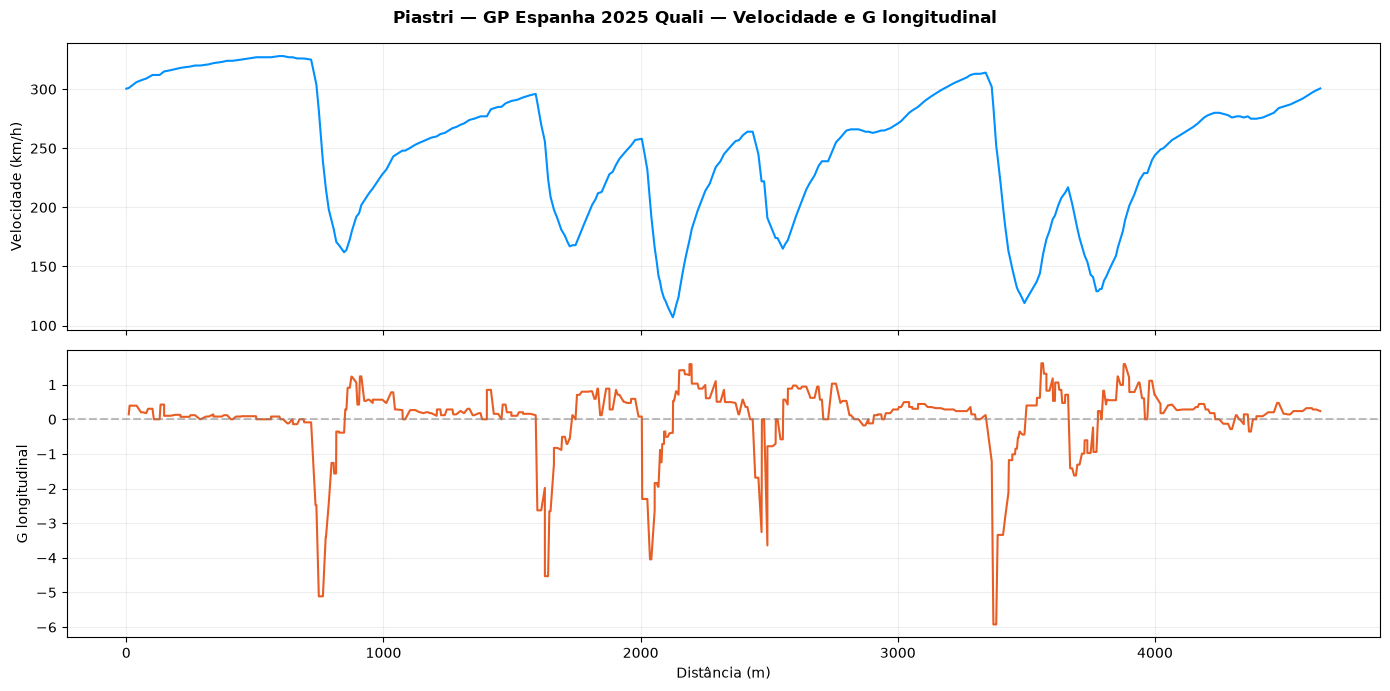

In [4]:
# Como g_longitudinal tem 1 elemento a menos, ajustamos a distância correspondente
distancia_g = tel_pia['Distance'].values[1:]  # remove o primeiro ponto

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(tel_pia['Distance'], tel_pia['Speed'], color='#0090FF')
axes[0].set_ylabel('Velocidade (km/h)')
axes[0].grid(alpha=0.2)

axes[1].plot(distancia_g, g_longitudinal, color='#E85D24')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('G longitudinal')
axes[1].set_xlabel('Distância (m)')
axes[1].grid(alpha=0.2)

fig.suptitle('Piastri — GP Espanha 2025 Quali — Velocidade e G longitudinal', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Defino um limite mínimo razoável pro intervalo de tempo
dt_minimo = 0.01  # 10ms — abaixo disso, consideramos erro de amostragem

# Máscara booleana: True onde o dt é "saudável"
mascara_valida = dt >= dt_minimo

# Aplica o filtro em tudo que depende de dt
dv_filtrado = dv[mascara_valida]
dt_filtrado = dt[mascara_valida]
distancia_filtrada = distancia_g[mascara_valida]

aceleracao_filtrada = dv_filtrado / dt_filtrado
g_filtrado = aceleracao_filtrada / 9.81

print(f"Pontos originais: {len(dt)}")
print(f"Pontos após filtro: {len(dt_filtrado)}")
print(f"Maior frenagem (filtrado): {g_filtrado.min():.2f} g")
print(f"Maior aceleração (filtrado): {g_filtrado.max():.2f} g")

Pontos originais: 543
Pontos após filtro: 513
Maior frenagem (filtrado): -5.92 g
Maior aceleração (filtrado): 1.62 g


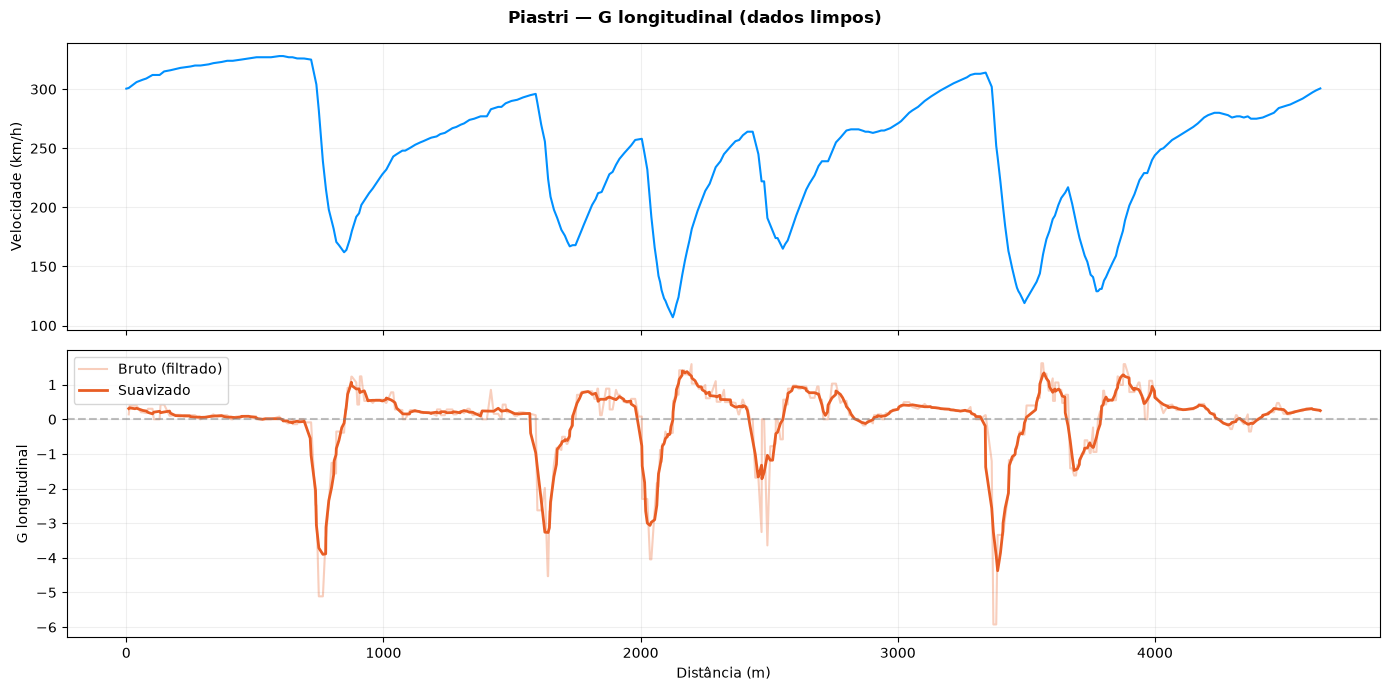

In [8]:
# Suaviza os dados já filtrados
v_para_suavizar = pd.Series(dv_filtrado / dt_filtrado)  # já é aceleração bruta
g_suave_filtrado = v_para_suavizar.rolling(window=5, center=True, min_periods=1).mean().values / 9.81

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(tel_pia['Distance'], tel_pia['Speed'], color='#0090FF')
axes[0].set_ylabel('Velocidade (km/h)')
axes[0].grid(alpha=0.2)

axes[1].plot(distancia_filtrada, g_filtrado, color='#E85D24', alpha=0.3, label='Bruto (filtrado)')
axes[1].plot(distancia_filtrada, g_suave_filtrado, color='#E85D24', linewidth=2, label='Suavizado')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('G longitudinal')
axes[1].set_xlabel('Distância (m)')
axes[1].legend()
axes[1].grid(alpha=0.2)

fig.suptitle('Piastri — G longitudinal (dados limpos)', fontweight='bold')
plt.tight_layout()
plt.show()

# Pós teste, como de costume, automatizamos...

In [9]:
def calcular_g_longitudinal(telemetria, dt_minimo=0.01, janela_suavizacao=5):
    """
    Calcula a força G longitudinal a partir da telemetria de uma volta.
    Filtra amostras com intervalo de tempo anormalmente pequeno (erro de sensor)
    e suaviza o resultado com média móvel.
    
    Retorna: distancia, g_bruto, g_suave (todos arrays numpy)
    """
    v_ms = telemetria['Speed'].values / 3.6
    t_s = telemetria['Time'].dt.total_seconds().values
    distancia = telemetria['Distance'].values
    
    dv = np.diff(v_ms)
    dt = np.diff(t_s)
    dist_pontos = distancia[1:]
    
    # Filtra dt anormalmente pequenos
    mascara_valida = dt >= dt_minimo
    dv_f = dv[mascara_valida]
    dt_f = dt[mascara_valida]
    dist_f = dist_pontos[mascara_valida]
    
    aceleracao = dv_f / dt_f
    g_bruto = aceleracao / 9.81
    
    g_suave = pd.Series(g_bruto).rolling(window=janela_suavizacao, center=True, min_periods=1).mean().values
    
    return dist_f, g_bruto, g_suave

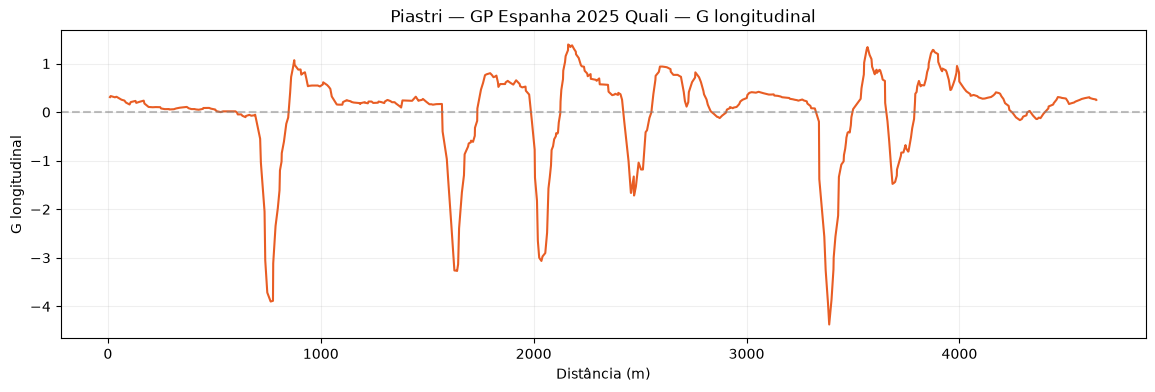

In [10]:
dist_pia, g_bruto_pia, g_suave_pia = calcular_g_longitudinal(tel_pia)

plt.figure(figsize=(14, 4))
plt.plot(dist_pia, g_suave_pia, color='#E85D24')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Distância (m)')
plt.ylabel('G longitudinal')
plt.title('Piastri — GP Espanha 2025 Quali — G longitudinal')
plt.grid(alpha=0.2)
plt.show()